In [25]:
import matplotlib.pyplot as plt, numpy as np, pandas as pd, time
from scipy.io import loadmat
from pprint import pprint
from scipy.signal import butter, filtfilt

In [18]:
mat = loadmat('Hanif_Visual_1.mat')

In [36]:
n_trials = 15
ch_trigger = 1
ch_bicep = 5
ch_brachio = 6

def get_epoch(channel, trial, file):
    start = file['datastart'][channel-1, trial] - 1
    end = file['dataend'][channel-1, trial]
    return file['data'][0][int(start):int(end)]

In [ ]:
# Extract epochs for all trials
trigger_epochs = np.array([get_epoch(ch_trigger, trial, mat) for trial in range(n_trials)])
bicep_epochs = np.array([get_epoch(ch_bicep, trial, mat) for trial in range(n_trials)])
brachio_epochs = np.array([get_epoch(ch_brachio, trial, mat) for trial in range(n_trials)])

# Rectification
triggers_rectified = np.abs(trigger_epochs)
biceps_rectified = np.abs(bicep_epochs)
brachios_rectified = np.abs(brachio_epochs)

# Envelope Extraction

Fs = 1000 # sampling rate
Flow = 10 # lowpass cutoff
Fhigh =  # highpass cutoff

b, a = butter(4, fc/(Fs/2), btype='low')

triggers_envelope = [filtfilt(b, a, trigger_rectified) for trigger_rectified in triggers_rectified]
biceps_envelope = [filtfilt(b, a, bicep_rectified) for bicep_rectified in biceps_rectified]
brachios_envelope = [filtfilt(b, a, brachio_rectified) for brachio_rectified in brachios_rectified]

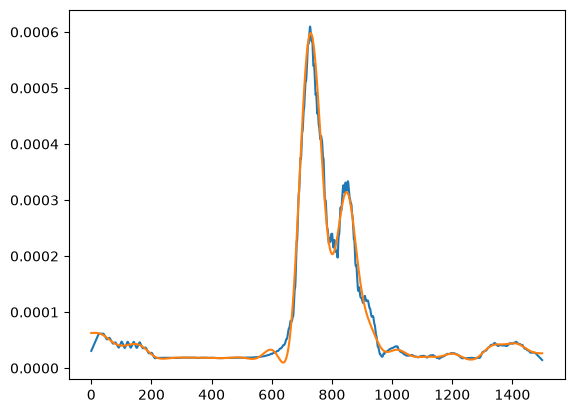

In [37]:
rectified = biceps_rectified[0]

envelope_ma = np.convolve(
    rectified,
    np.ones(50)/50,
    mode='same'
)

plt.plot(envelope_ma)
plt.plot(biceps_envelope[0])

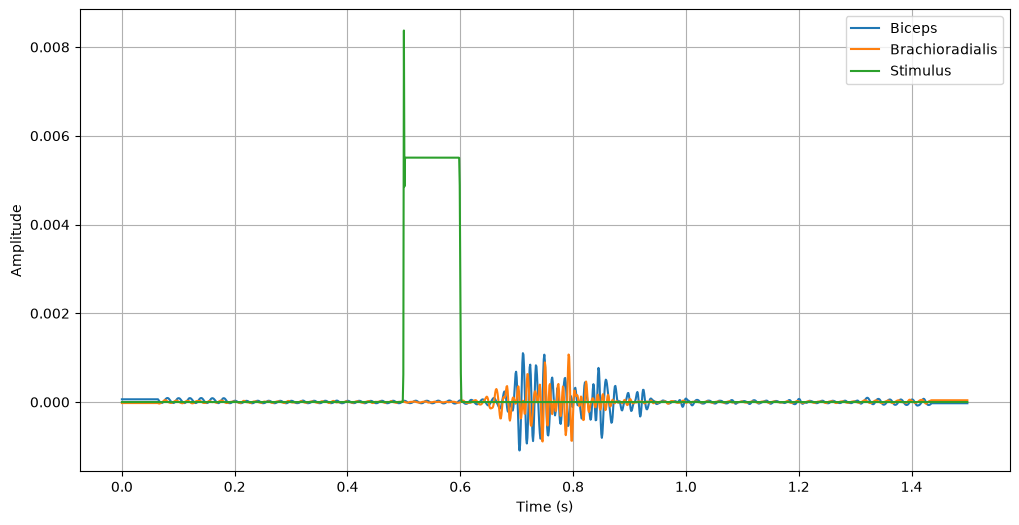

In [44]:
trial = 0

stim = get_epoch(ch_trigger, trial, mat)
biceps = get_epoch(ch_bicep, trial, mat)
brachio = get_epoch(ch_brachio, trial, mat)

t = np.arange(len(stim)) / 1000  # Fs = 1000 Hz

plt.figure(figsize=(12,6))

plt.plot(t, biceps, label="Biceps")
plt.plot(t, brachio, label="Brachioradialis")
plt.plot(t, stim * np.max(np.abs(biceps)), label="Stimulus")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()

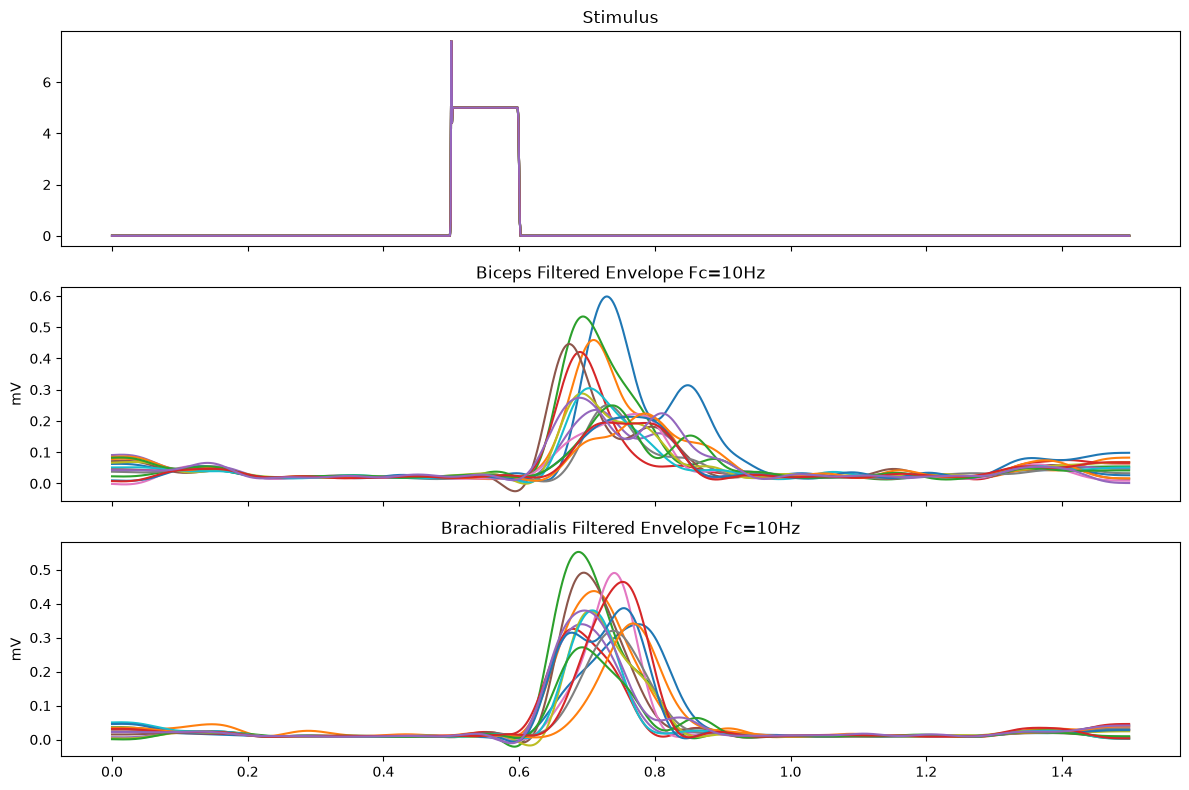

In [53]:
fig, ax = plt.subplots(3, 1, figsize=(12,8), sharex=True)


ax[0].set_title("Stimulus")

ax[1].set_title("Biceps Filtered Envelope Fc=10Hz")
ax[2].set_title("Brachioradialis Filtered Envelope Fc=10Hz")

for trial in range(n_trials):
  ax[0].plot(t, trigger_epochs[trial])
  ax[1].plot(t, biceps_envelope[trial] * 1000)
  ax[2].plot(t, brachios_envelope[trial] * 1000)

ax[1].set_ylabel("mV")
ax[2].set_ylabel("mV")

plt.tight_layout()
plt.show()

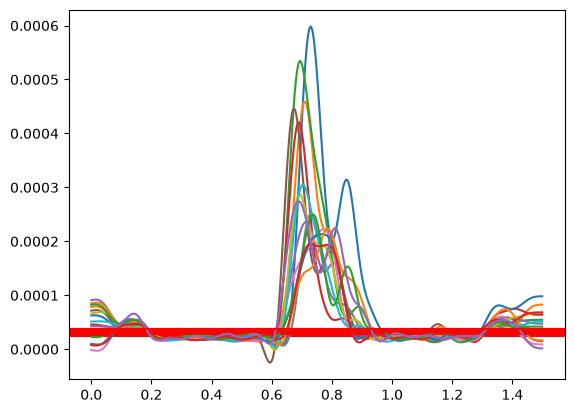

In [62]:
for envelope in biceps_envelope:
  baseline = envelope[200:500]  #64ms to 500ms (stimuli @500ms)
  mu = np.mean(baseline)
  sigma = np.std(baseline)
  threshold = mu + 5*sigma
  plt.plot(t, envelope)
  plt.axhline(threshold, color='r')

plt.show()
  

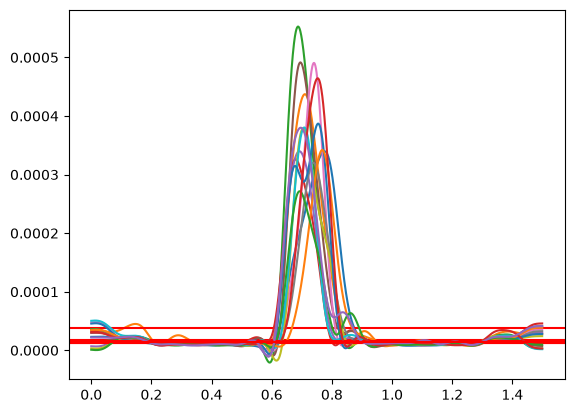

In [63]:
for envelope in brachios_envelope:
  baseline = envelope[200:500]  #64ms to 500ms (stimuli @500ms)
  mu = np.mean(baseline)
  sigma = np.std(baseline)
  threshold = mu + 5*sigma
  plt.plot(t, envelope)
  plt.axhline(threshold, color='r')

plt.show()
  